In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import transforms

sys.path.append(os.path.abspath(os.path.join("../..")))
from src.models.crnn.crnn_v1 import Captcha_CRNN_V1
from src.datasets.huggingfacefilelistdataset import HuggingFaceFileListDataset

In [2]:
captcha_transformation = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((40, 150)),
        transforms.ToTensor(),
    ]
)
dataset = HuggingFaceFileListDataset(
    file_list="/nfs/home/tpz8688/Captcha-Recognition/notebooks/data-cleaning/clean_images_v2.txt", 
    transform=captcha_transformation
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Captcha_CRNN_V1(num_chars=len(dataset.vocab) + 1)
state_dict = torch.load(Captcha_CRNN_V1.SAVE_DIR / "v4.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval() 

print(f"Model successfully loaded from {Captcha_CRNN_V1.SAVE_DIR / "v4.pth"}")

Model successfully loaded from /nfs/home/tpz8688/Captcha-Recognition/weights/crnn/v4.pth


In [4]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        # Check if the output is a tuple (standard for LSTM/RNN layers)
        if isinstance(output, tuple):
            # Take only the first element (the output tensor)
            activations[name] = output[0].detach()
        else:
            # Standard tensor (standard for Conv/Linear layers)
            activations[name] = output.detach()
    return hook

In [5]:
# --- Convolutional Backbone (The "Eyes") ---
model.conv_layer[0].register_forward_hook(get_activation('cnn_1_conv'))
model.conv_layer[1].register_forward_hook(get_activation('cnn_1_bn'))
model.conv_layer[2].register_forward_hook(get_activation('cnn_1_silu'))
model.conv_layer[3].register_forward_hook(get_activation('cnn_1_pool'))

model.conv_layer[4].register_forward_hook(get_activation('cnn_2_conv'))
model.conv_layer[5].register_forward_hook(get_activation('cnn_2_bn'))
model.conv_layer[6].register_forward_hook(get_activation('cnn_2_silu'))
model.conv_layer[7].register_forward_hook(get_activation('cnn_2_pool'))

model.conv_layer[8].register_forward_hook(get_activation('cnn_3_conv'))
model.conv_layer[9].register_forward_hook(get_activation('cnn_3_bn'))
model.conv_layer[10].register_forward_hook(get_activation('cnn_3_silu'))
model.conv_layer[11].register_forward_hook(get_activation('cnn_3_asym_pool'))

model.conv_layer[12].register_forward_hook(get_activation('cnn_4_conv'))
model.conv_layer[13].register_forward_hook(get_activation('cnn_4_bn'))
model.conv_layer[14].register_forward_hook(get_activation('cnn_4_silu'))

# --- Recurrent Stage (The "Brain") ---
model.lstm.register_forward_hook(get_activation('rnn_sequence'))

# --- Output Stage (The "Voice") ---
model.classifier.register_forward_hook(get_activation('output_logits'))

In [13]:
def plot_captcha(image_tensor, title=None):
    # Remove batch dimension if present
    if image_tensor.dim() == 4: # [Batch, C, H, W]
        image_tensor = image_tensor.squeeze(0)
    
    # Move to CPU and convert to numpy
    img = image_tensor.detach().cpu().numpy()
    
    # If grayscale [1, H, W], squeeze to [H, W]
    if img.shape[0] == 1:
        img = img.squeeze(0)
    else:
        # If RGB [3, H, W], transpose to [H, W, 3]
        img = np.transpose(img, (1, 2, 0))

    # Reverse normalization if mean=[0.5] and std=[0.5] was used
    # img = img * 0.5 + 0.5 

    plt.figure(figsize=(8, 3))
    plt.imshow(img, cmap='gray' if image_tensor.shape[0] == 1 else None)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [14]:
image, label, length = dataset[2]
input_tensor = image.unsqueeze(0).to(device)

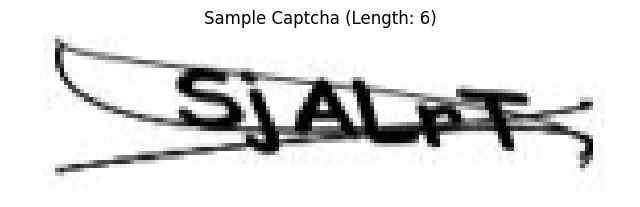

In [15]:
plot_captcha(image, title=f"Sample Captcha (Length: {length})")

In [16]:
_ = model(input_tensor)

In [17]:
def plot_feature_maps(activation, title, num_cols=8):
    # activation is [1, Channels, H, W]
    channels = activation.shape[1]
    num_rows = channels // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*2, num_rows*1))
    fig.suptitle(title, fontsize=16)
    
    for i in range(channels):
        ax = axes[i // num_cols, i % num_cols]
        # Show each channel's feature map
        ax.imshow(activation[0, i].cpu(), cmap='magma')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [18]:
def plot_rnn_activations(activation, title="LSTM Hidden States"):
    # activation shape: [1, Time, Features] -> [37, 512]
    # We remove batch and transpose to get [Features, Time] for a better vertical plot
    data = activation.squeeze(0).cpu().numpy().T 
    
    plt.figure(figsize=(15, 8))
    # We use a heatmap to see which features are "firing" at each time step
    sns.heatmap(data, cmap='viridis', cbar=True)
    
    plt.title(title)
    plt.xlabel("Time (Sequence Steps)")
    plt.ylabel("LSTM Hidden Features (512)")
    plt.show()

In [19]:
def plot_final_predictions(activation, vocab_list):
    # activation: [1, 37, 63] -> Squeeze and Transpose to [63, 37]
    data = activation.squeeze(0).cpu().numpy().T
    
    plt.figure(figsize=(20, 12))
    sns.heatmap(data, cmap='viridis', yticklabels=vocab_list)
    
    plt.title("CTC Logits: Character Probability per Time Step")
    plt.xlabel("Time (Visual Slices from CNN)")
    plt.ylabel("Characters")
    plt.show()

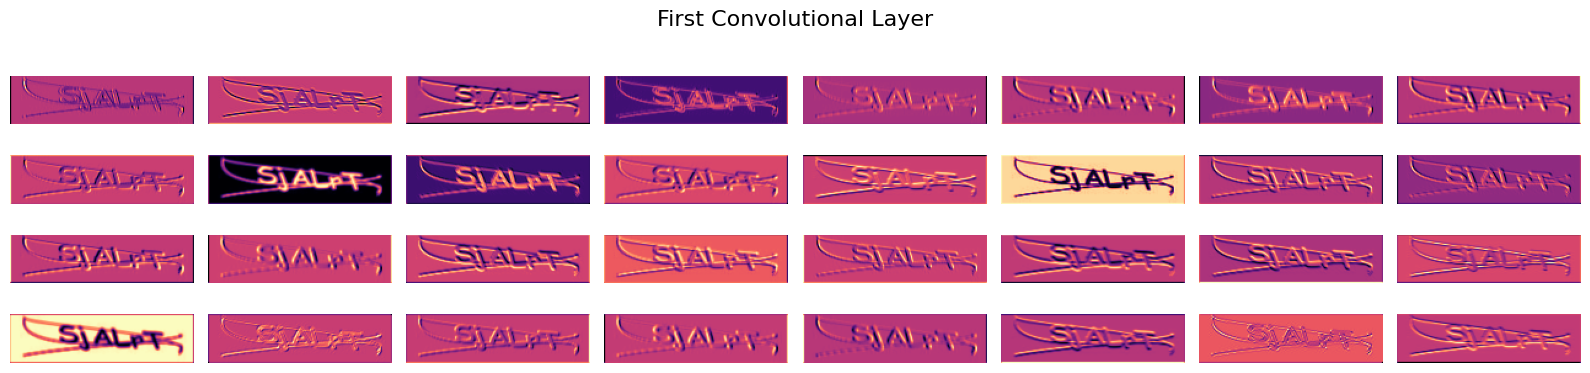

In [20]:
plot_feature_maps(activations['cnn_1_conv'], "First Convolutional Layer")

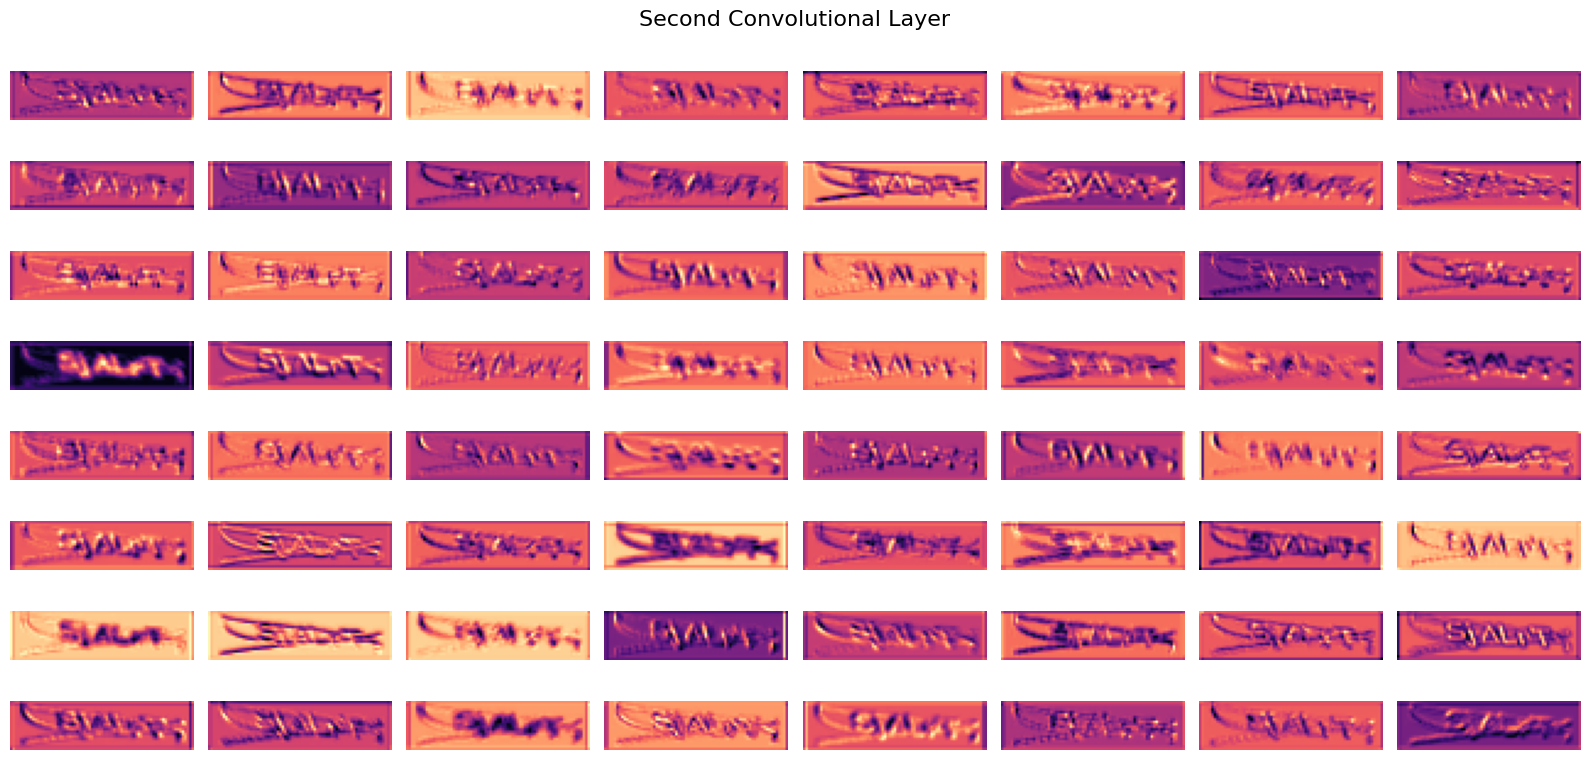

In [21]:
plot_feature_maps(activations['cnn_2_conv'], "Second Convolutional Layer")

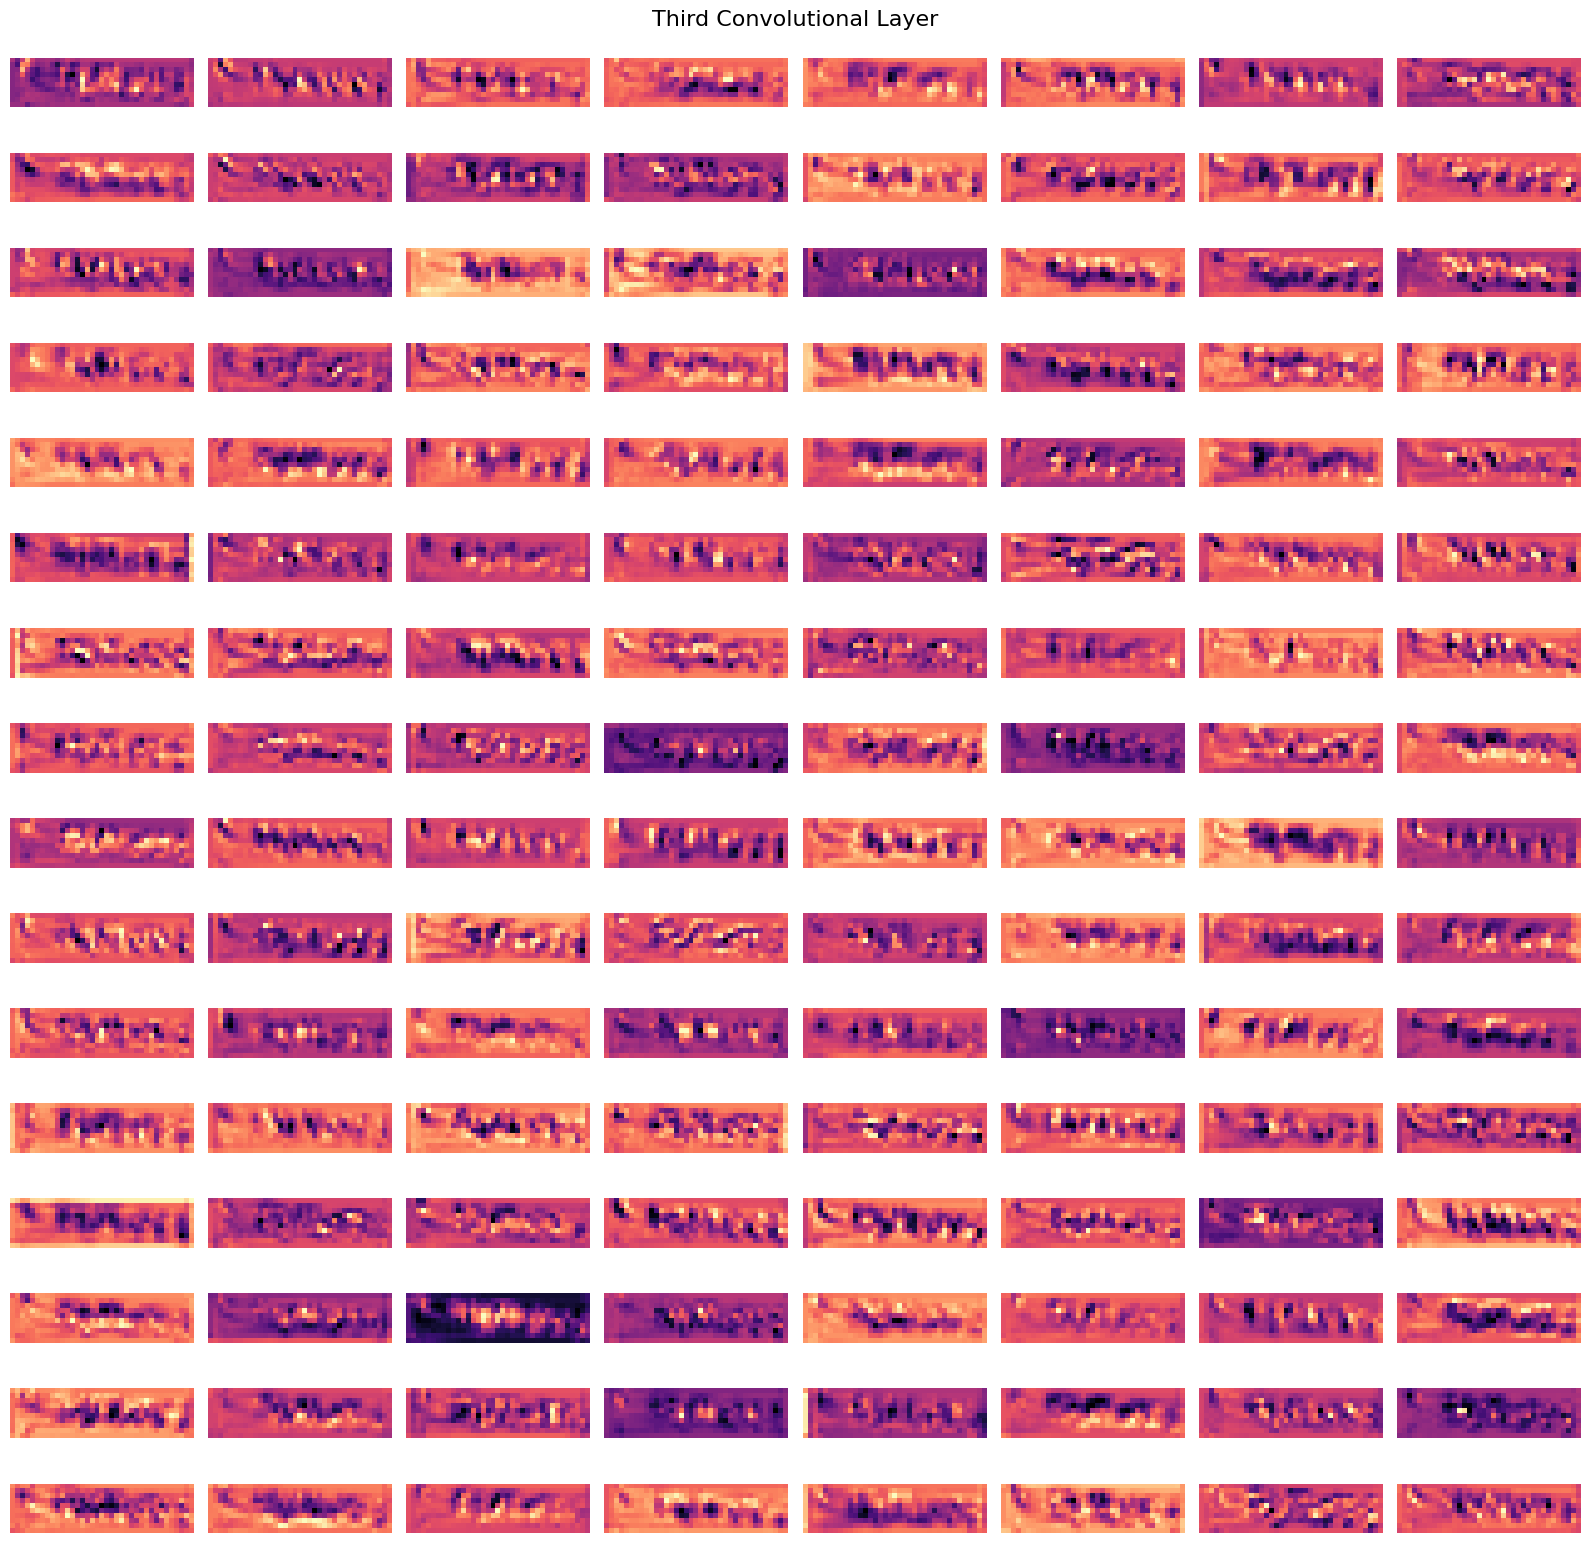

In [22]:
plot_feature_maps(activations['cnn_3_conv'], "Third Convolutional Layer")

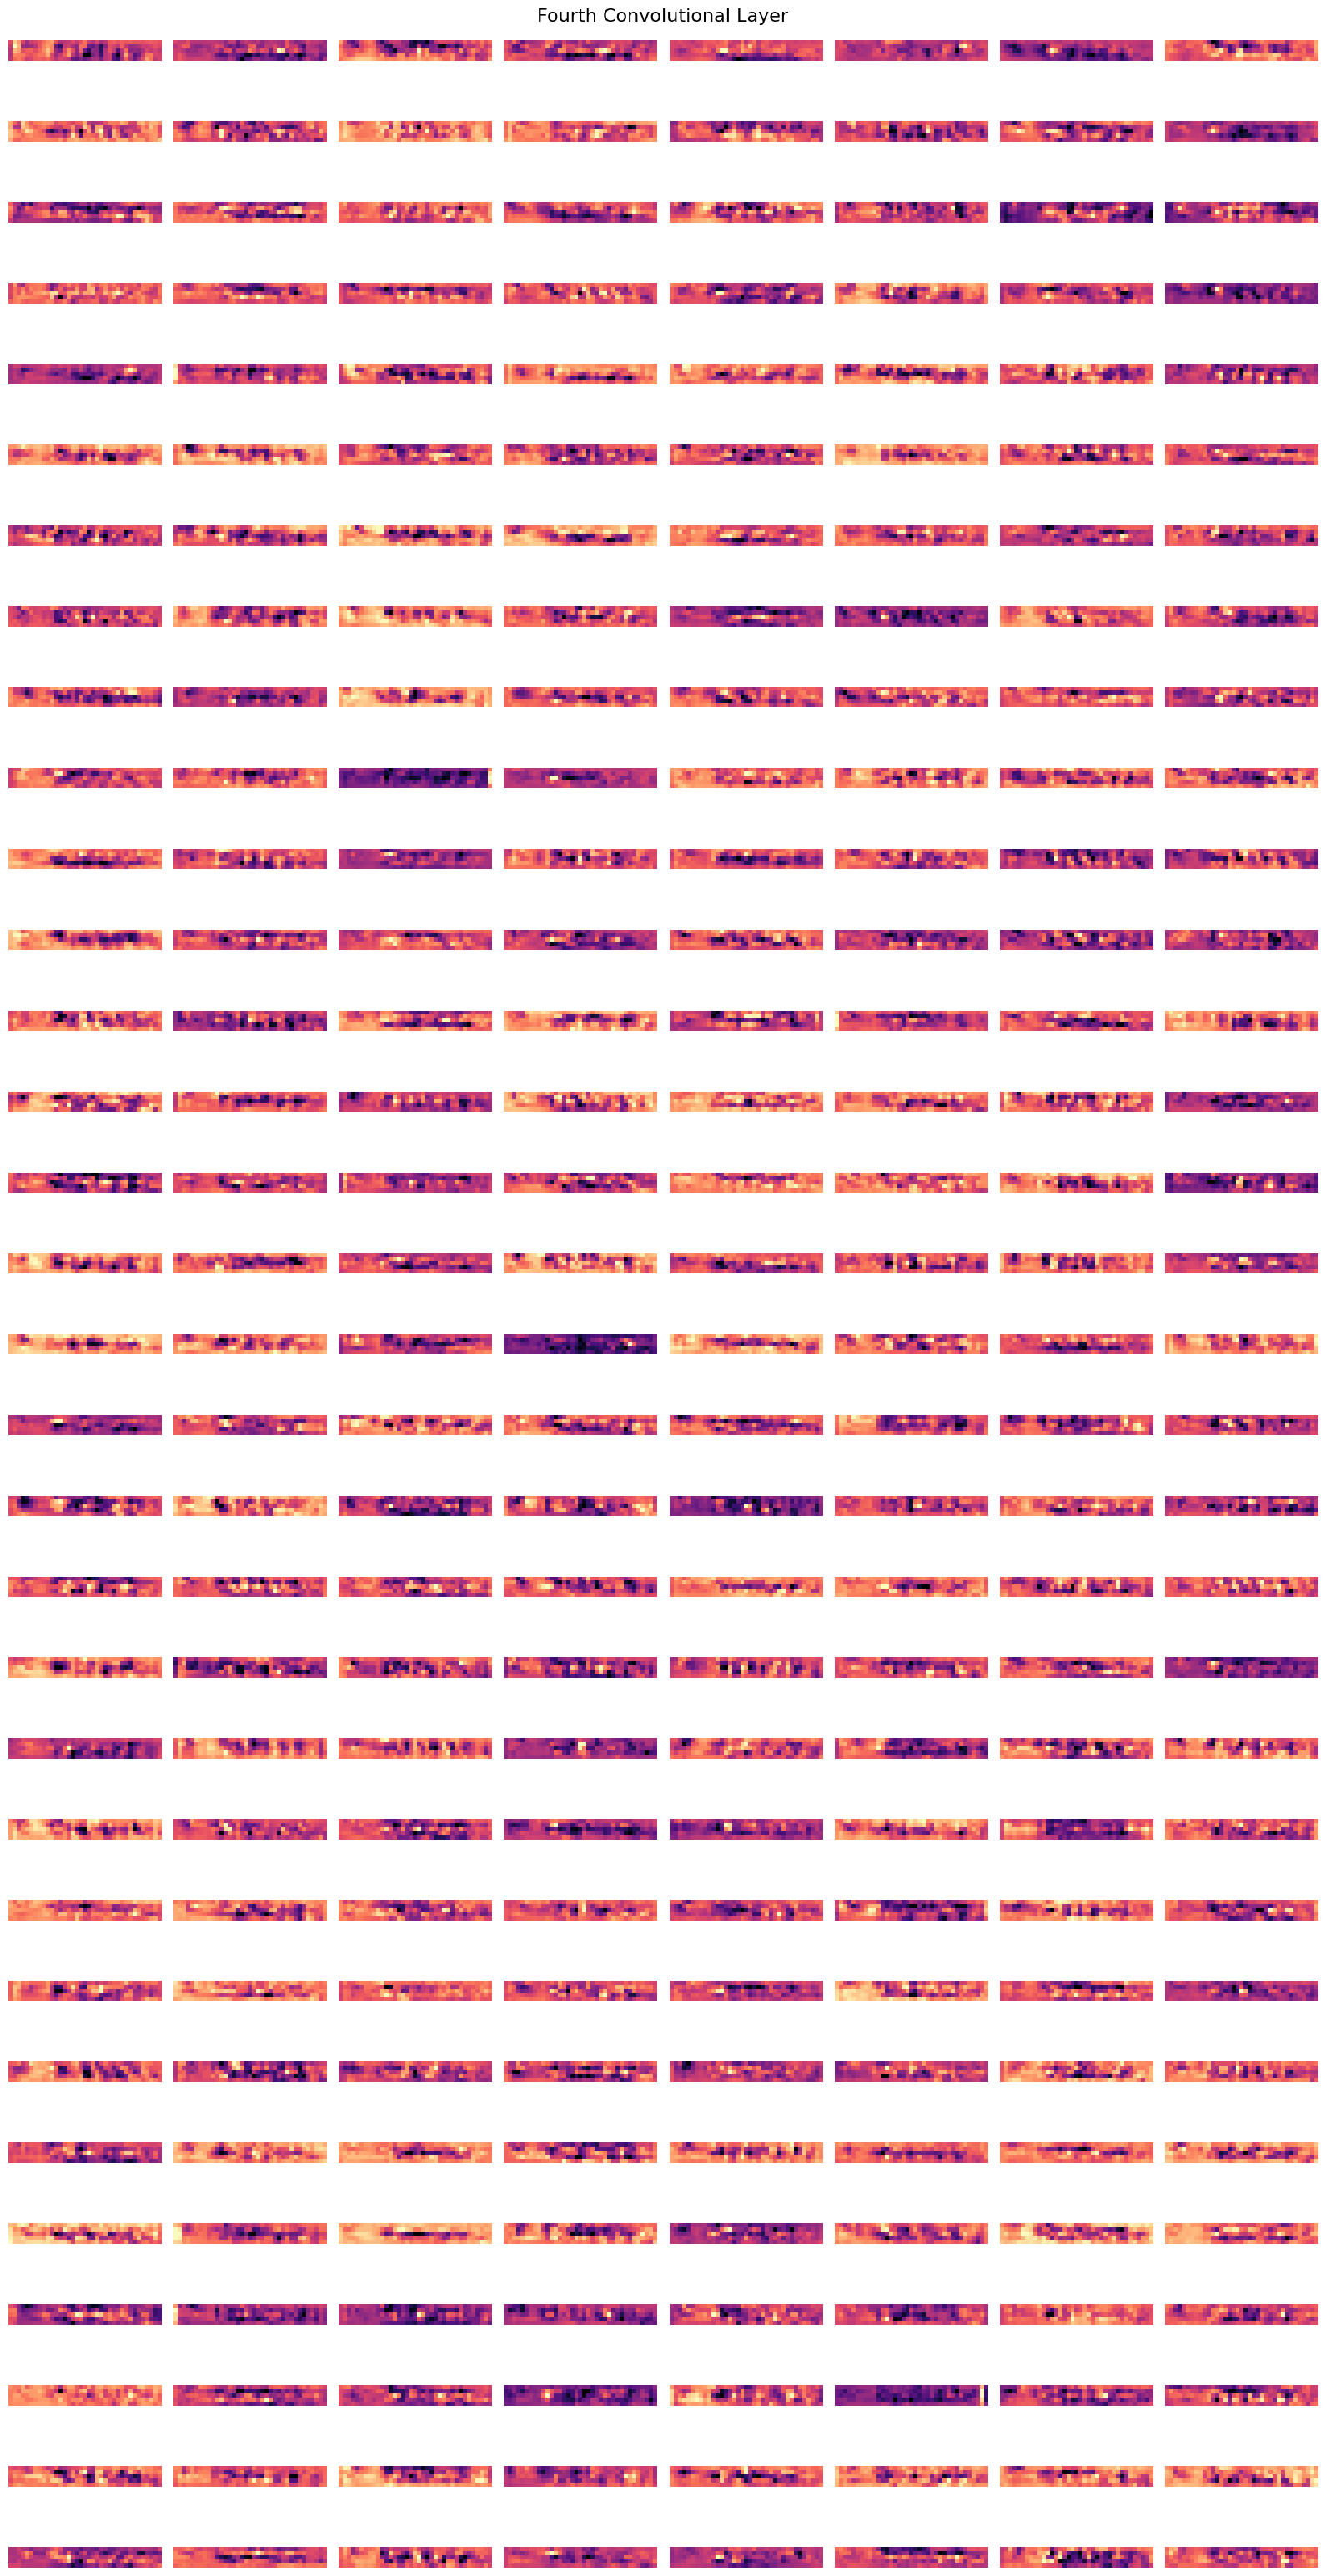

In [23]:
plot_feature_maps(activations['cnn_4_conv'], "Fourth Convolutional Layer")

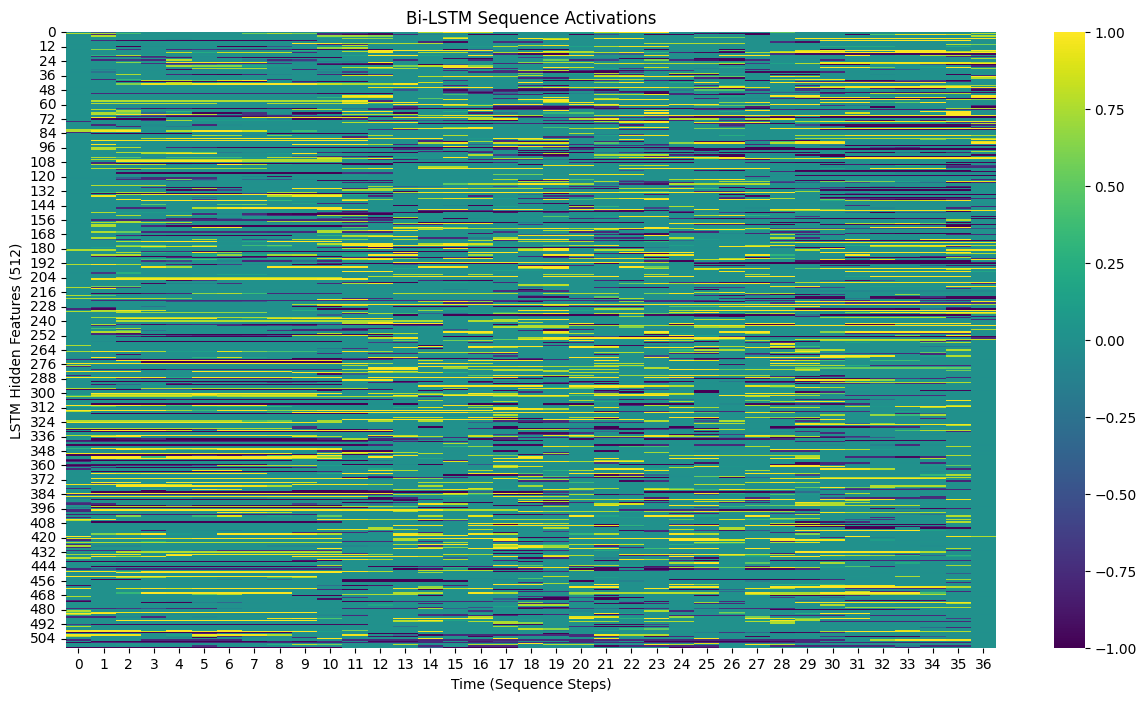

In [24]:
plot_rnn_activations(activations['rnn_sequence'], "Bi-LSTM Sequence Activations")

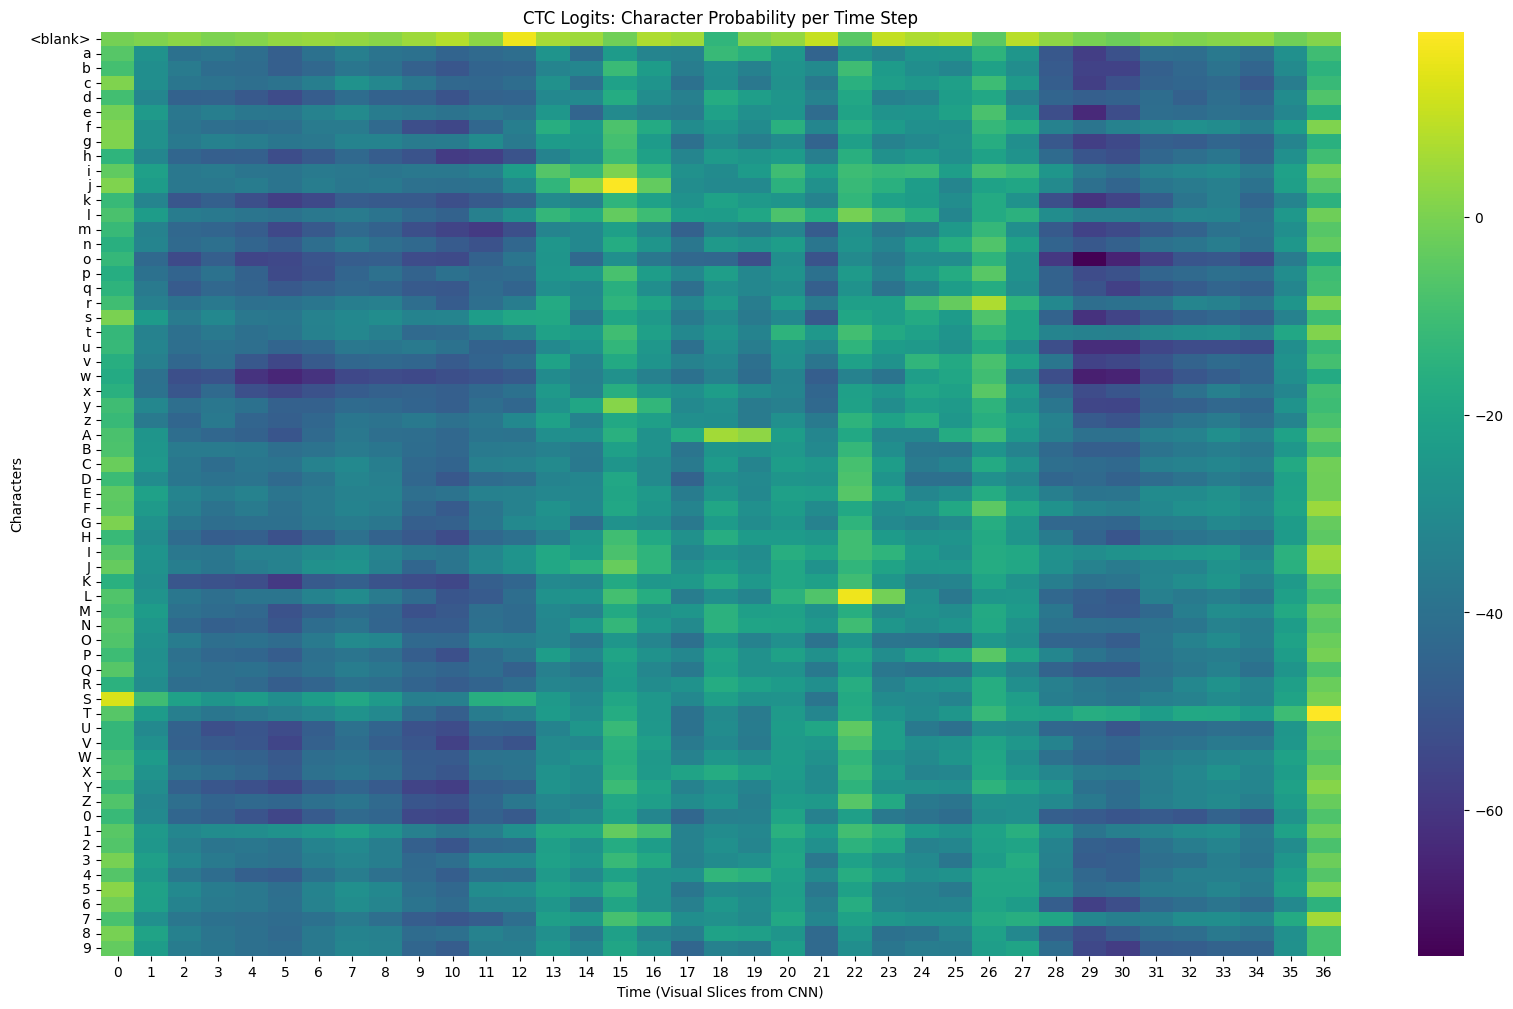

In [25]:
vocab_list = ["<blank>"] + [dataset.idx_to_char[i] for i in range(1, len(dataset.vocab) + 1)]
plot_final_predictions(activations['output_logits'], vocab_list)

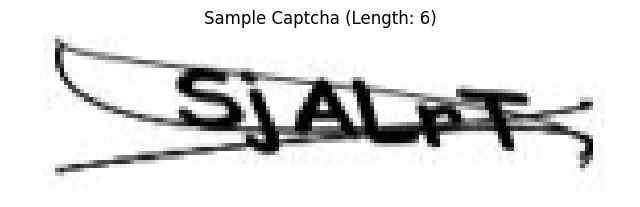

In [26]:
plot_captcha(image, title=f"Sample Captcha (Length: {length})")